In [ ]:
# Preamble
%load_ext autoreload
# %load_ext memory_profiler
%autoreload 2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import maglab.formats.mumax3 as mx3
import maglab.loaders.mumax3 as l_mx3
import maglab.analysis.spectral as rd
import maglab.loaders.ringdown as l_rd
import maglab.loaders.utils as l_ut
import maglab.processing.state as p_state

Loading OVF files: 100%|██████████| 601/601 [00:00<00:00, 5616.14 files/s]


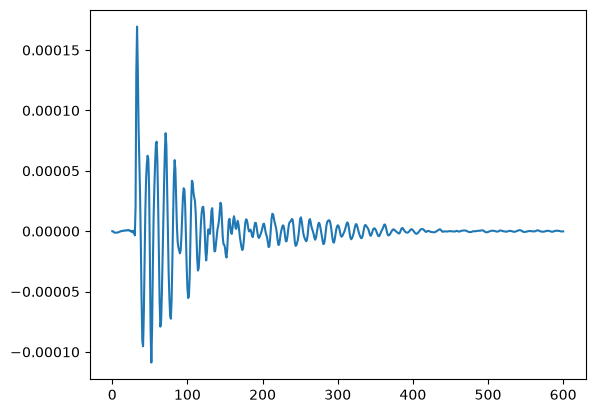

In [2]:
dirpath = r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_nomask_test.out"

f, kx, ky, _ = l_rd.load_reciprocal_axes(dirpath)
arr = l_mx3.load_multiple_ovf_array(dirpath, direction=(0, 0, 1), zslice=0)
plt.plot(np.mean(arr, axis=(1, 2, 3, 4)))
plt.show()

sigma_k = 10e6
KX_DoS, KY_DoS = np.meshgrid(kx, ky, indexing="ij")
Gaussian2D = np.exp(-(KX_DoS**2 + KY_DoS**2) / (2 * sigma_k**2))
filt = Gaussian2D
arr = arr[:, 0, :, :, 0]

arr = rd.calc_masked_wavevector_spectrum(arr, filt=filt, s_axes=(1, 2))





(0.0, 20.0)

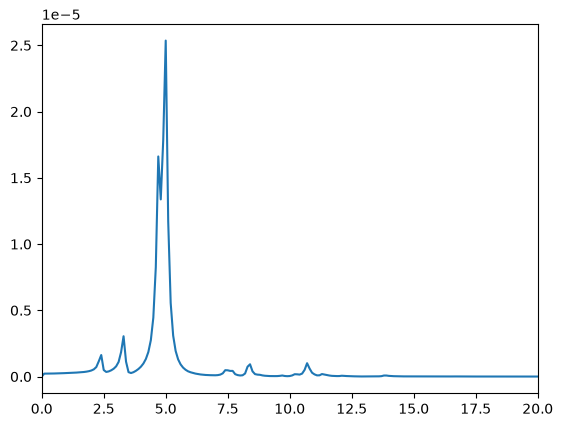

In [3]:
bls = rd.calc_incoherent(arr)
plt.plot(f/1e9, bls)
plt.xlim(0, 20)

In [4]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"
table = mx3.read_table(TABLE_PATH)
# table.loc[0, ["mx ()", "my ()", "mz ()"]].to_numpy()
# table.loc[:, table.columns.str.contains("mx|my|mz")]
# table.loc[0, table.columns.str.contains("B_extx|B_exty|B_extz")]
l_ut.compute_dot_vectors(table, ["m", "B_ext"], direction="B_ext")
# table

[array([-1.12721540e-10,  4.52447720e-07,  8.95513100e-07, ...,
        -1.61017460e-08, -1.38172185e-08, -1.07641210e-08], shape=(1201,)),
 array([ 8.3346096e-22,  7.8623110e-08, -2.2975273e-09, ...,
         1.8228659e-10,  4.0687160e-09,  2.3830931e-23], shape=(1201,))]

(0.0, 18.0)

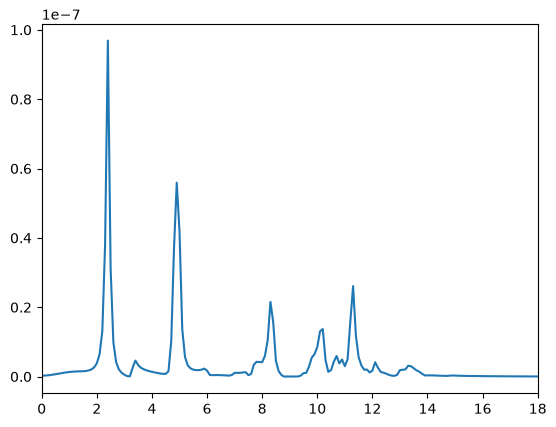

In [4]:
TABLE_PATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out") / "table.txt"

df = l_rd.load_mag_avg_ringdown(TABLE_PATH)
plt.plot(df["frequency"], df["absorption"])
plt.xlim(0, 18)

In [49]:
dfs = []
for i in [10, 20, 30, 40, 60, 80, 150]:
    dirpath = Path(fr"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_kc{i}.out")
    _, freqs, bls, fmr = l_rd.load_ringdown(dirpath)
    df = pd.DataFrame({"frequency": freqs, f"BLS kc {-i}": bls, f"FMR kc {-i}": fmr})
    dfs.append(df)

Loading OVF files: 100%|██████████| 1201/1201 [00:02<00:00, 569.69 files/s]


Loading OVF files: 100%|██████████| 1201/1201 [00:02<00:00, 586.47 files/s]


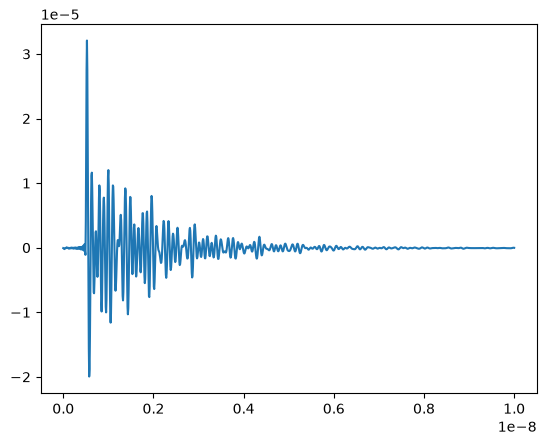

In [34]:
# DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-05-22 AASI Dynamics 2x2\1-1\1-1_phi0_3\1-1_phi0_3exct_B000060.out")
# DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct.out")
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-21 15nm ASI BLS\E3_256_m100.out")
# (psd, phase), (frequencies, psd_spectrum) = l_rd.load_ringdown(DIRPATH)
# plt.plot(frequencies, psd_spectrum)

spec, freqs, bls, fmr = l_rd.load_ringdown(DIRPATH)

In [ ]:
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_nomask_damp.out")
absorption, (f, kx, ky) = l_rd.load_dispersion(DIRPATH)

Loading OVF files: 100%|██████████| 1201/1201 [00:00<00:00, 1702.56 files/s]


In [53]:
tot_df = pd.concat(dfs, axis=1)
tot_df = tot_df.loc[:, ~tot_df.columns.duplicated()]
tot_df.to_csv("kc.csv")
# tot_df.loc[:900, :]

Text(0, 0.5, 'BLS intensity (arb. units.)')

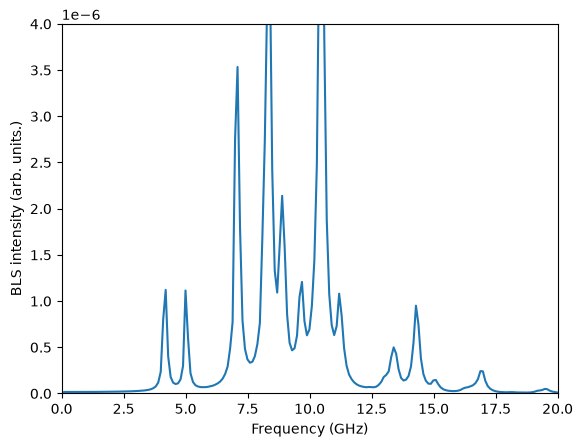

In [46]:
plt.plot(freqs / 1e9, bls)
plt.xlim(0, 20)
# plt.ylim(0, 0.3e-6)
# plt.ylim(0, 0.2e-8)
# plt.ylim(0, 1.2e-6)
# plt.ylim(0, 5e-6)
# plt.ylim(0, 3e-7)
plt.ylim(0, 4e-6)
# plt.ylim(0, 4000e-8)
# plt.ylim(0, 1000e-8)
plt.xlabel("Frequency (GHz)")
plt.ylabel("BLS intensity (arb. units.)")


In [49]:
blss.append(bls)

In [45]:
labels = [r"$\text{10}^\text{-5}$", r"$\text{10}^\text{-6}$", r"$\text{10}^\text{-7}$", r"$\text{10}^\text{-8}$"]
for i, b in enumerate(blss):
    plt.plot(freqs / 1e9, b, label = labels[i])
plt.xlim(0, 20)
# plt.ylim(0, 1.2e-6)
plt.ylim(0, 4e-6)
plt.xlabel("Frequency (GHz)")
plt.ylabel("BLS intensity (arb. units.)")
plt.legend(title="MaxErr")

NameError: name 'blss' is not defined

In [ ]:
import pandas as pd
df = pd.DataFrame({"frequency": freqs, -5: blss[0], -6: blss[1], -7: blss[2], -8: blss[3]})


,frequency,-5,-6,-7,-8
0,0.000000e+00,3.744772e-10,4.480344e-10,4.593269e-10,3.409070e-10
1,9.991674e+07,3.040068e-08,1.647327e-08,1.611581e-08,1.606322e-08
2,1.998335e+08,4.126367e-08,1.726781e-08,1.690396e-08,1.703770e-08
3,2.997502e+08,3.640177e-08,1.845320e-08,1.819095e-08,1.826842e-08
4,3.996669e+08,3.656750e-08,2.007266e-08,1.983422e-08,2.008630e-08
...,...,...,...,...,...
596,5.955037e+10,4.011078e-07,4.410792e-09,3.560643e-11,8.882536e-11
597,5.965029e+10,4.271107e-07,6.465083e-09,3.461282e-11,9.034260e-11
598,5.975021e+10,4.311520e-07,4.399629e-09,3.356432e-11,9.632617e-11
599,5.985012e+10,3.459628e-07,3.081498e-09,3.519175e-11,1.017561e-10


In [ ]:
times = [304.0, 300.9, 302.3, 1022.9]
steps = [39729, 39729, 39780, 152939]

In [ ]:
times = [224.9, 198.6, 195.4, 474.7]
steps = [39730, 39727, 39767, 152996]


In [39]:
blss = []

In [22]:
DIRPATH = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_nomask_damp_lowtstep2.out")

spec = l_rd.load_spec_array(DIRPATH)
freqs, *_ = l_rd.load_reciprocal_axes(DIRPATH)
bls = rd.calc_incoherent(spec)
fmr = rd.calc_coherent(spec)

Loading OVF files: 100%|██████████| 401/401 [00:00<00:00, 611.90 files/s]


(201,) (201,)


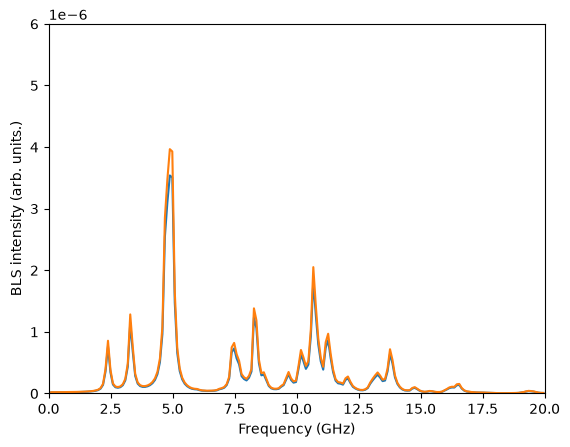

In [23]:
a, b = 85, 171
xrange = (b, a)
yrange = (a, b)

mask_v = p_state.boundary_slice_mask(spec.shape, [slice(None), slice(None), slice(b, a), slice(a, b)])
mask_h = p_state.boundary_slice_mask(spec.shape, [slice(None), slice(None), slice(a, b), slice(b, a)])
bls_h = rd.calc_incoherent(spec[mask_h])
bls_v = rd.calc_incoherent(spec[mask_v])
bls = rd.calc_incoherent(spec)
print(bls_v.shape, freqs.shape)
# plt.plot(freqs/1e9, bls_h)
# plt.plot(freqs/1e9, bls_v)
plt.plot(freqs/1e9, bls * 4)
plt.plot(freqs/1e9, bls_h + bls_v)
plt.xlim(0, 20)
plt.ylim(0, 0.6e-5)
plt.xlabel("Frequency (GHz)")
plt.ylabel("BLS intensity (arb. units.)")
plt.show()


In [28]:
print(kx.min(), kx.max())

-893608577.0210966 886627260.0131193


In [7]:
dirpath = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-21 15nm ASI BLS\E3_256_m100.out")
# dirpath = Path(r"C:\Users\qqhx82\OneDrive - Durham University\PhD Files\Simulations\2026-09-18 ASI Test\E3_256_m200_exct_damp.out")
disp = l_rd.load_dispersion_array(dirpath, zslice=0)
f, kx, ky, kz = l_rd.load_reciprocal_axes(dirpath)
kx = kx / 1e6
ky = ky / 1e6
n_ky = len(ky)
n_kx = len(kx)
FFT = disp[:, 0, :, :, 0].transpose(2, 1, 0)

Loading OVF files: 100%|██████████| 1201/1201 [00:01<00:00, 843.94 files/s]


In [10]:
FFT.shape

(256, 256, 601)

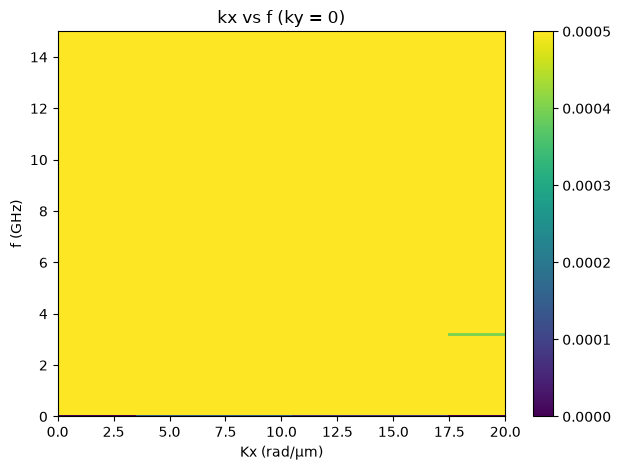

In [13]:


FFTKy0 = np.abs(FFT[:, n_ky // 2, :]) ** 2

# FFTKy0 = np.abs(np.mean(FFT[:, :, :], 1)) ** 2

# Create meshgrid for kx and f.
# Note: MATLAB's ndgrid corresponds to indexing='ij' in numpy.meshgrid.
KX, F_grid = np.meshgrid(kx, f, indexing="ij")


plt.figure(num="Dispersion for Ky = 0")
pcm = plt.pcolormesh(KX, F_grid*1e-9, FFTKy0, shading="auto", cmap="viridis")
plt.xlabel("Kx (rad/μm)")
plt.ylabel("f (GHz)")
plt.title("kx vs f (ky = 0)")
plt.xlim([0, 20])
# plt.xlim([-50, 50])
plt.ylim([0, 15])
plt.clim(0, 5e-4)
plt.colorbar(pcm)
plt.tight_layout()

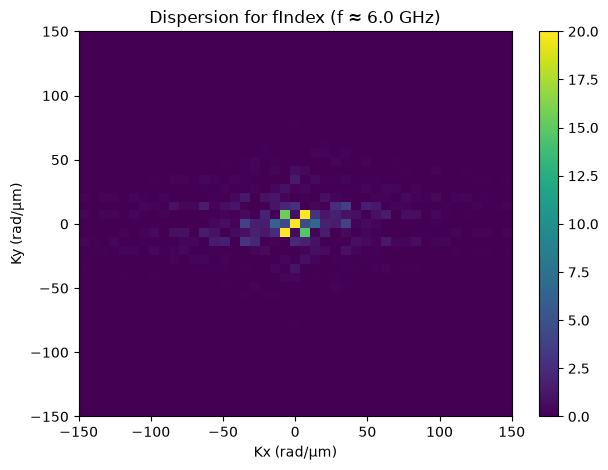

In [9]:
# --- Plot 3: Dispersion for a Selected Frequency (fIndex) ---
# Find index corresponding to frequency closest to 16 GHz.
f_target = 6.0e9
fIndex = np.argmin(np.abs(f - f_target))
FFTfIndex = np.abs(FFT[:, :, fIndex]) ** 2

# Create meshgrid for kx and ky.
KX3, KY3 = np.meshgrid(kx, ky, indexing="ij")

plt.figure(num="Dispersion for fIndex")
pcm = plt.pcolormesh(KX3, KY3, FFTfIndex, shading="auto", cmap="viridis")
plt.xlabel("Kx (rad/μm)")
plt.ylabel("Ky (rad/μm)")
plt.title(f"Dispersion for fIndex (f ≈ {f_target/1e9:.1f} GHz)")
plt.xlim([-150, 150])
plt.ylim([-150, 150])
# plt.xlim([-100, 100])
# plt.ylim([-100, 100])
plt.clim(0, 20)
# plt.clim(0, 10e-4)
# plt.clim(0, 200e-4)
plt.colorbar(pcm)
plt.tight_layout()

# plt.show()
# plt.savefig(f"dispersion {f_target / 1e9:.0f} pad.png", dpi=200)

-893.6085770210966 886.6272600131193
(601,)
float32


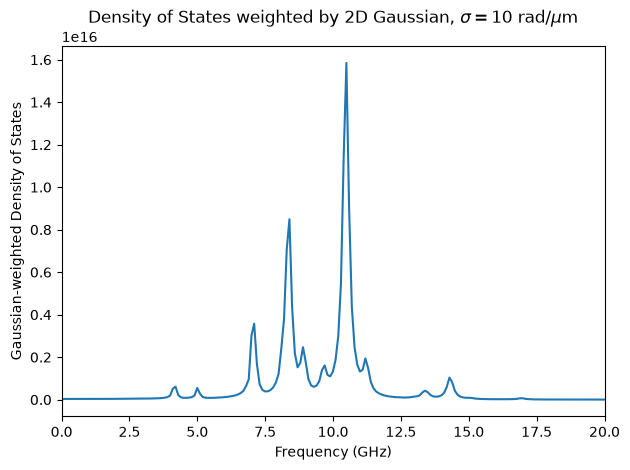

In [10]:
sigma_k = 20.0  # rad/µm

KX_DoS, KY_DoS = np.meshgrid(kx, ky, indexing="ij")

print(KX_DoS.min(), KY_DoS.max())

Gaussian2D = np.exp(-(KX_DoS**2 + KY_DoS**2) / (2 * sigma_k**2))



FFT_ = FFT * 800e3

DoS_Gaussian = np.sum(
    abs(FFT_)**2 * Gaussian2D[:, :, None],
    axis=(0, 1), dtype=np.float32
)
print(DoS_Gaussian.shape)
print(DoS_Gaussian.dtype)
plt.figure(num="Density of States - Gaussian weighted")
plt.plot(f * 1e-9, DoS_Gaussian)
plt.xlabel("Frequency (GHz)")
plt.ylabel("Gaussian-weighted Density of States")
plt.title(r"Density of States weighted by 2D Gaussian, $\sigma = 10$ rad/$\mu$m")
plt.xlim([0, 20])
# plt.ylim(0, 0.9e12)
# plt.ylim(0, 0.9e9)
# plt.ylim(0, 0.2e12)
plt.tight_layout()
plt.savefig("spectrum pad.png", dpi=200)

In [5]:
horizontal = (60, 120), (120, 60)
vertical = (60, 120), (120, 60)

a, b = 85, 171

# xrange = (a, b)
# yrange = (b, a)

xrange = (b, a)
yrange = (a, b)

spec = arr
from scipy.signal import find_peaks
bls = rd.calc_incoherent(spec)
mask=mask_h
peak_idxs, _ = find_peaks(bls[:300], height=np.max(bls[:300])*1e-3)
for f_idx in peak_idxs[2:]:
    print(freqs[f_idx] / 1e9)
    print()
    s = spec[mask]
    s = s[f_idx].mean(axis=0)                    # average over z
    print(np.abs(np.sum(s**2)) / np.sum(np.abs(s)**2))
    s *= np.exp(-1j*np.angle(s.flat[np.argmax(np.abs(s))]))
    v = np.abs(s.real).max()
    s[s == 0.0] = np.nan
    plt.imshow(s.real, cmap='RdBu_r', vmin=-v, vmax=v)
    # plt.imshow(np.log(s.real), cmap="RdBu_r")
    plt.colorbar()
    plt.show()

NameError: name 'mask_h' is not defined

4.196502914238135

0.9766742


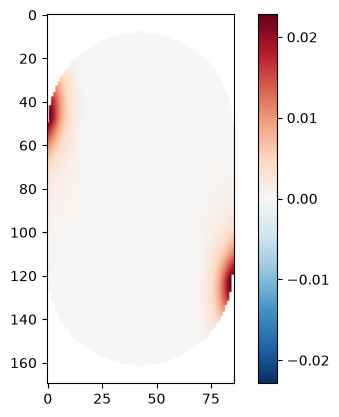

7.094088259783513

0.9700629


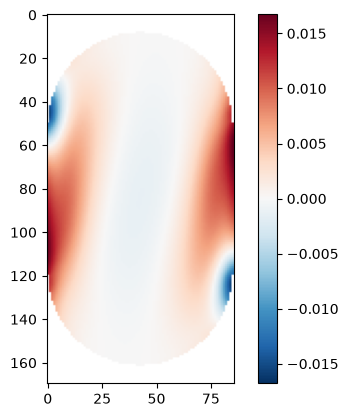

8.39300582847627

0.9324998


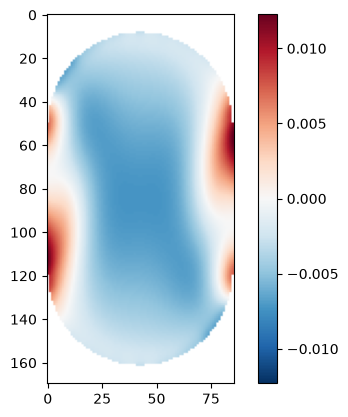

8.792672772689425

0.44707918


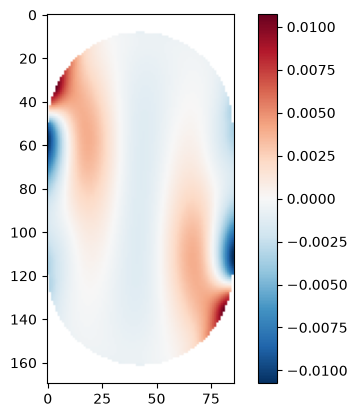

9.691923397169026

0.20067893


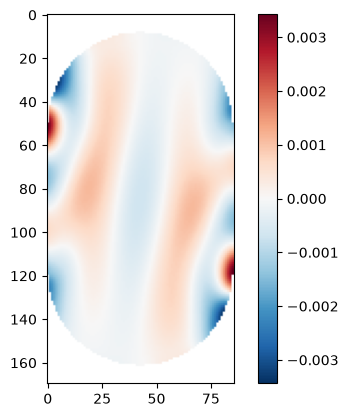

10.091590341382181

0.53343856


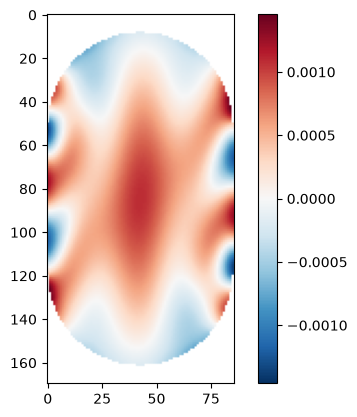

10.391340549542047

0.47183856


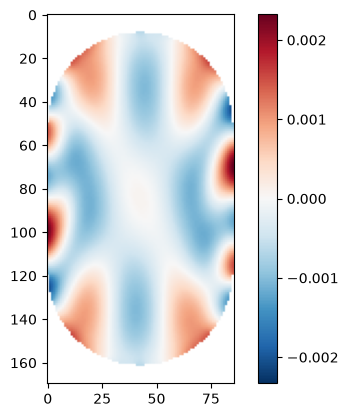

11.19067443796836

0.96116817


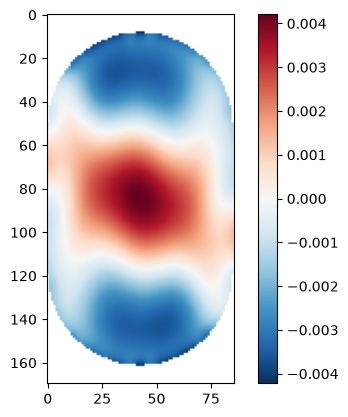

12.389675270607826

0.5184163


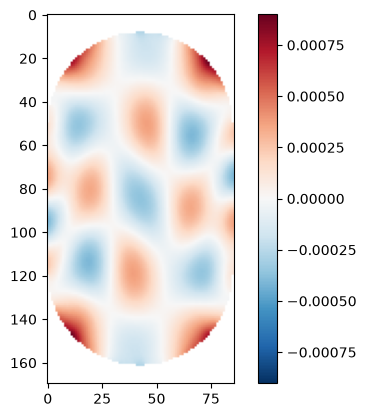

13.388842631140715

0.90632784


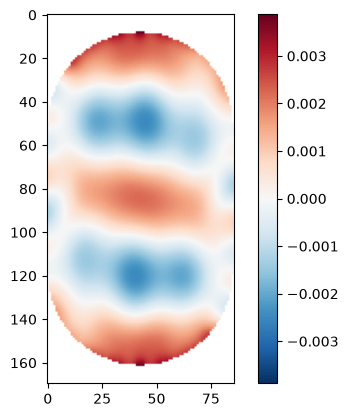

15.087427144046627

0.8494795


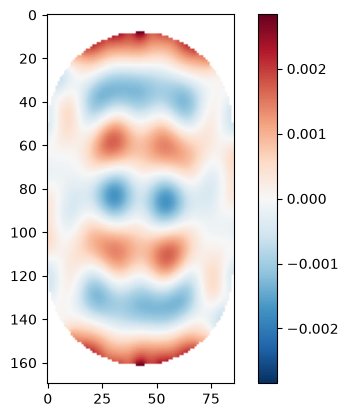

16.68609492089925

0.7792973


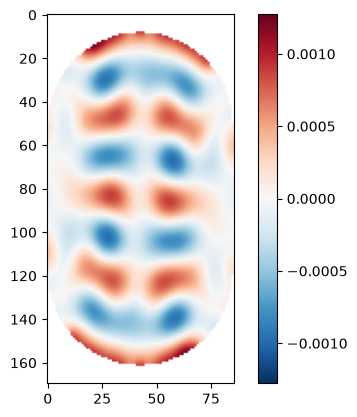

18.184845961698585

0.46251857


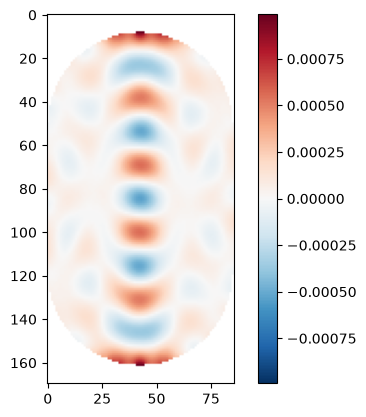

18.484596169858452

0.12277708


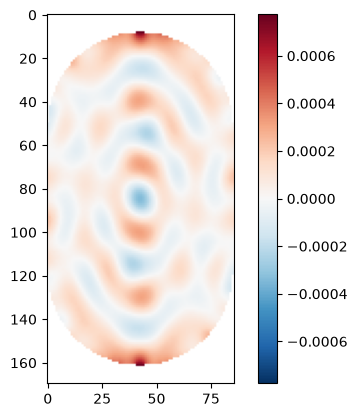

In [ ]:
horizontal = (60, 120), (120, 60)
vertical = (60, 120), (120, 60)

a, b = 85, 171

# xrange = (a, b)
# yrange = (b, a)

xrange = (b, a)
yrange = (a, b)


from scipy.signal import find_peaks
bls = bls_v
peak_idxs, _ = find_peaks(bls[:300], height=np.max(bls[:300])*1e-3)
f_idx = 56
mask = p_state.boundary_slice_mask(spec.shape, [slice(None), slice(None), slice(*xrange), slice(*yrange)])
for f_idx in peak_idxs[2:]:
    print(freqs[f_idx] / 1e9)
    print()
    s = spec[mask_v]
    s = s[f_idx].mean(axis=0)                    # average over z
    print(np.abs(np.sum(s**2)) / np.sum(np.abs(s)**2))
    s *= np.exp(-1j*np.angle(s.flat[np.argmax(np.abs(s))]))
    v = np.abs(s.real).max()
    s[s == 0.0] = np.nan
    plt.imshow(s.real, cmap='RdBu_r', vmin=-v, vmax=v)
    # plt.imshow(np.log(s.real), cmap="RdBu_r")
    plt.colorbar()
    plt.show()

[  1   4  42  50  71  84  89  97 105 112 124 134 143 151 169 181 185 195
 217 224 246 260 277 281 287 291]


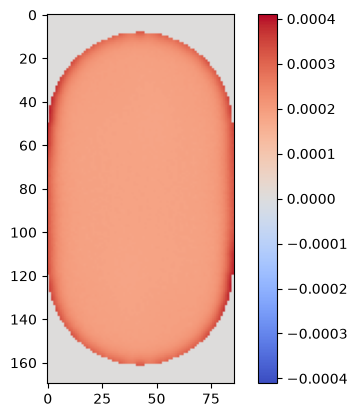

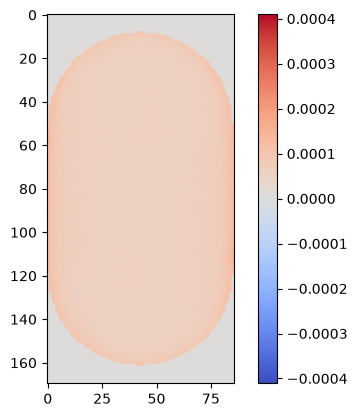

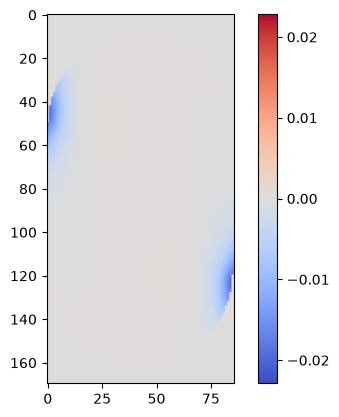

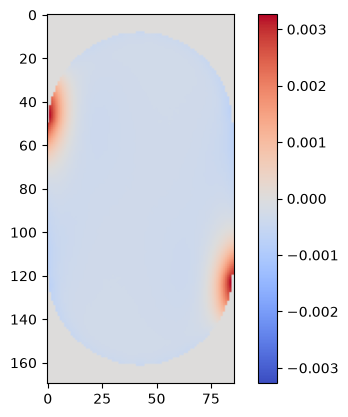

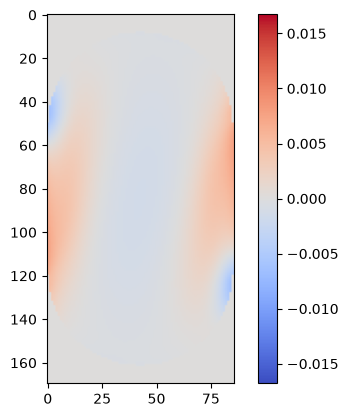

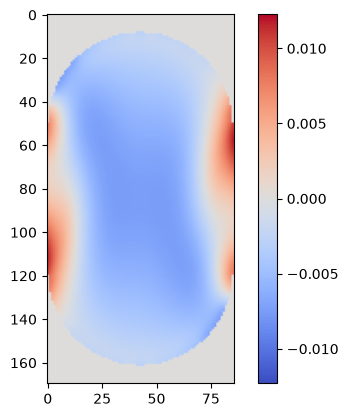

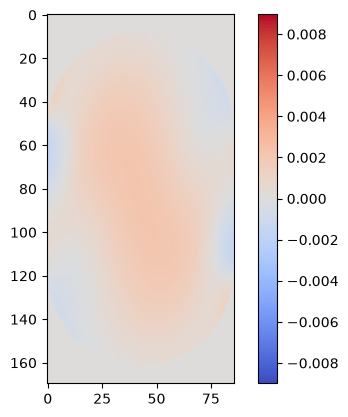

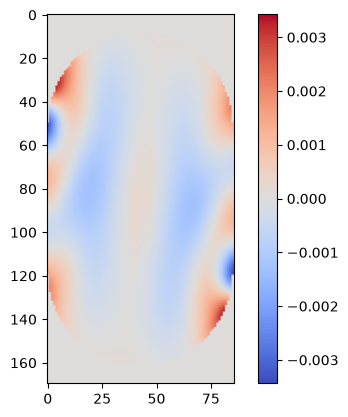

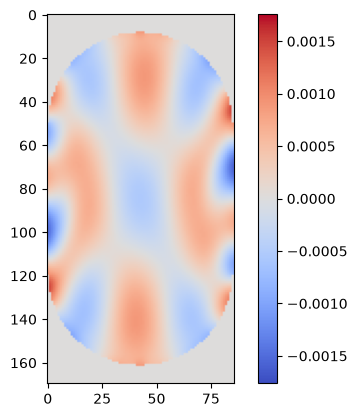

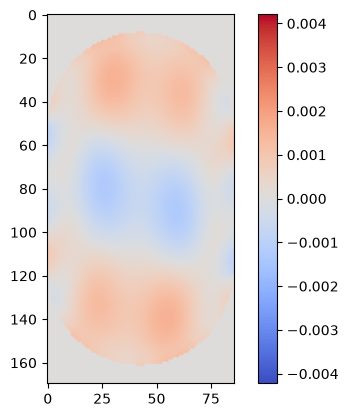

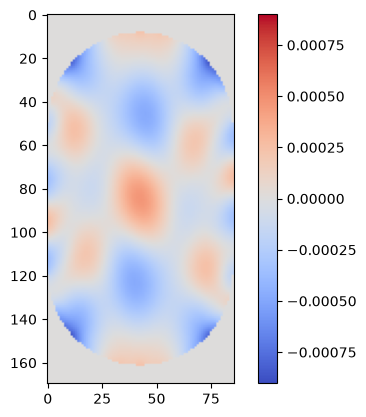

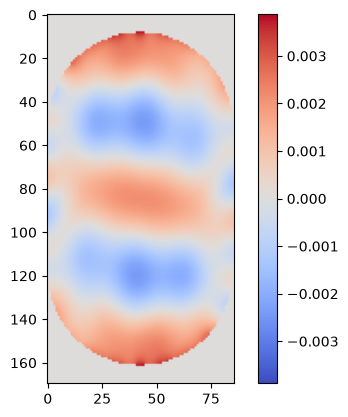

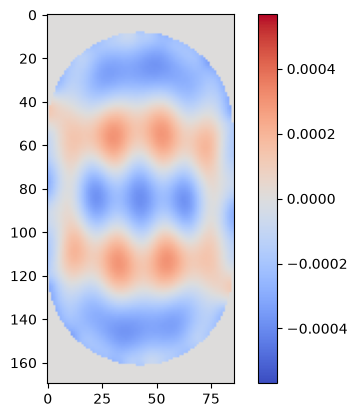

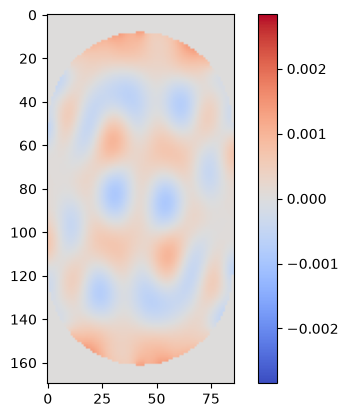

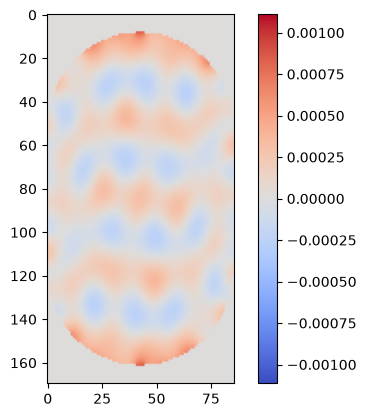

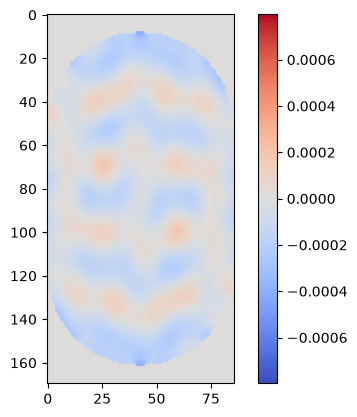

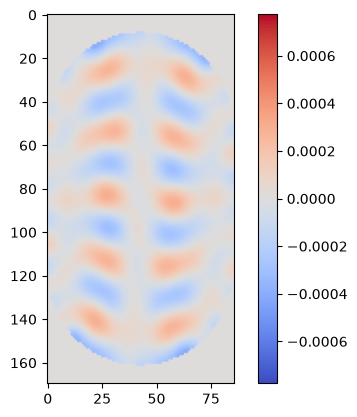

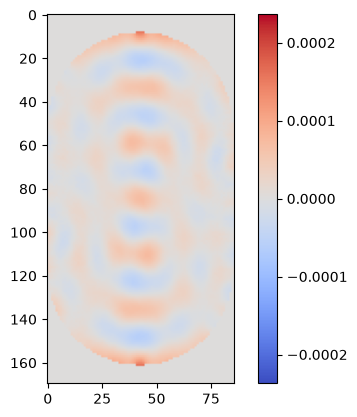

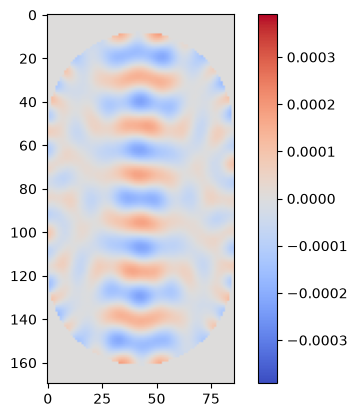

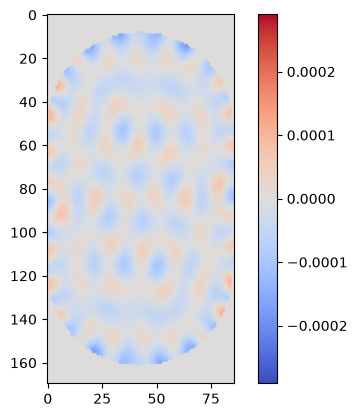

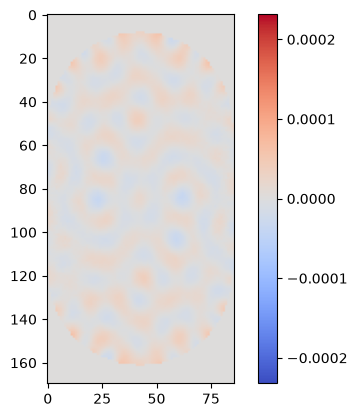

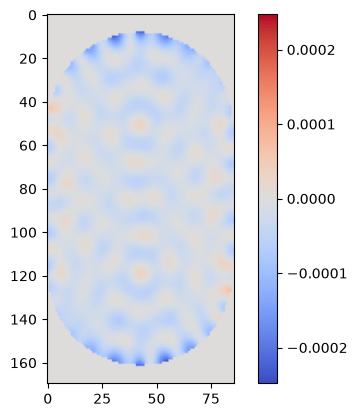

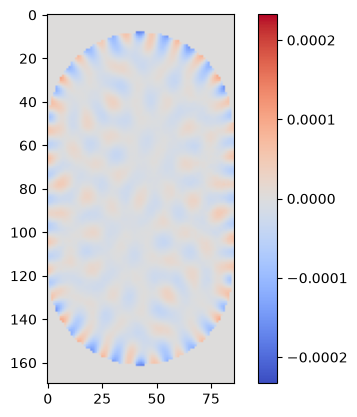

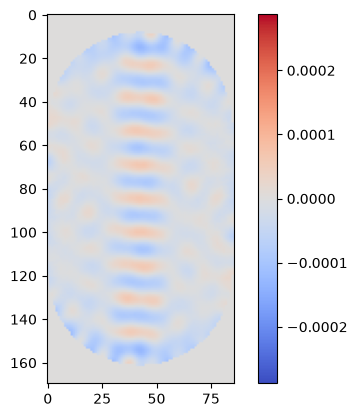

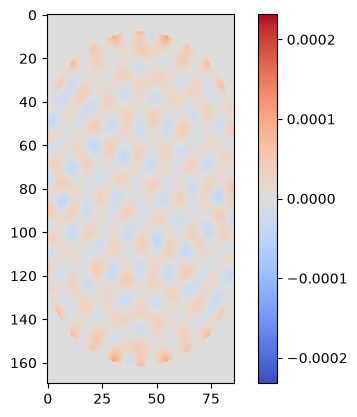

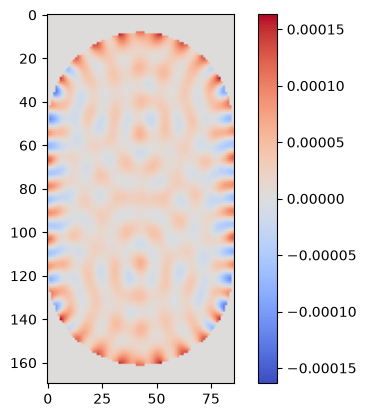

In [55]:
horizontal = (60, 120), (120, 60)
vertical = (60, 120), (120, 60)

a, b = 85, 171

# xrange = (a, b)
# yrange = (b, a)

xrange = (b, a)
yrange = (a, b)

print(peak_idxs)
from scipy.signal import find_peaks
peak_idxs, _ = find_peaks(bls[:300])
f_idx = 56
mask = p_state.boundary_slice_mask(spec.shape, [slice(None), slice(None), slice(*xrange), slice(*yrange)])
for f_idx in peak_idxs:
    s = spec[mask]
    s = s[f_idx].mean(axis=0)                    # average over z
    amp = abs(s)
    phase = np.angle(s)
    v = amp.max()
    # s *= np.exp(-1j*np.angle(s.flat[np.argmax(np.abs(s))]))
    # v = np.abs(s.real).max()
    # s[s == 0.0] = np.nan

    p = amp * np.cos(phase)
    # plt.imshow(s.real, cmap='RdBu_r', vmin=-v, vmax=v)
    # plt.imshow(np.log(s.real), cmap="RdBu_r")
    plt.imshow(p, cmap='coolwarm', vmin=-v, vmax=v)
    plt.colorbar()
    plt.show()

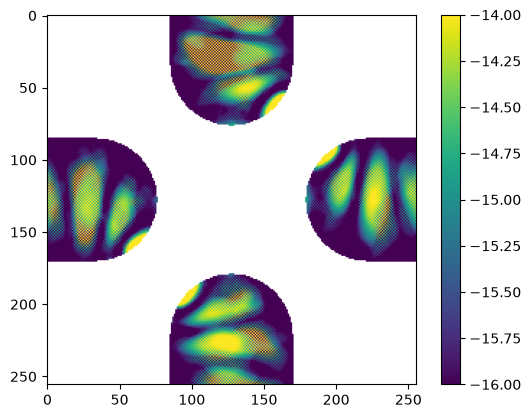

In [40]:
plt.imshow(np.log(psd[46, 4, ...]), clim=(-16, -14))
plt.colorbar()